In [1]:
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import pmdarima as pm

# graphiques dans le notebook
%matplotlib inline

warnings.filterwarnings("ignore")
np.random.seed(42)

df = pd.read_csv("data/btc_eth_processed.csv", parse_dates=["date"], index_col="date").asfreq("D")  # données préparées
split = json.load(open("data/split.json"))                                                          # même split que l'équipe

H = 10      # horizon de prévision (10 jours)
D = 1       # ordre de différenciation (conclu par ADF/KPSS)

print(split)

{'train_end': '2025-11-14', 'test_start': '2025-11-15', 'test_end': '2026-09-30', 'n_train': 2875, 'n_test': 320}


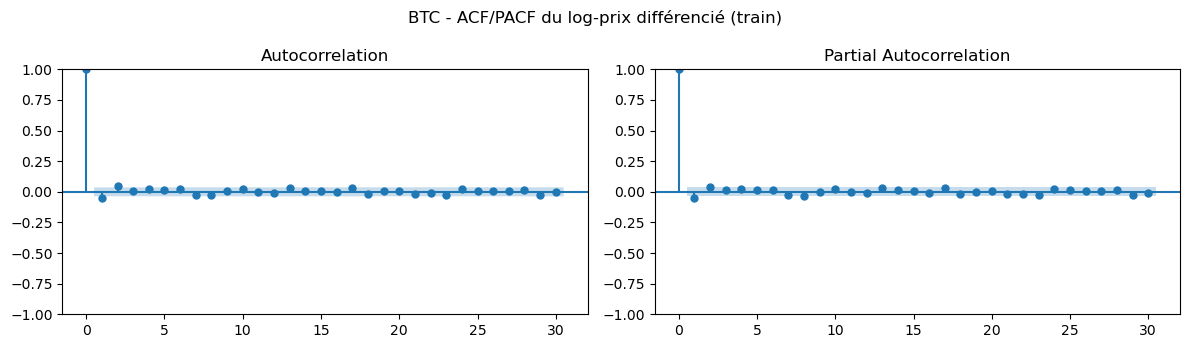

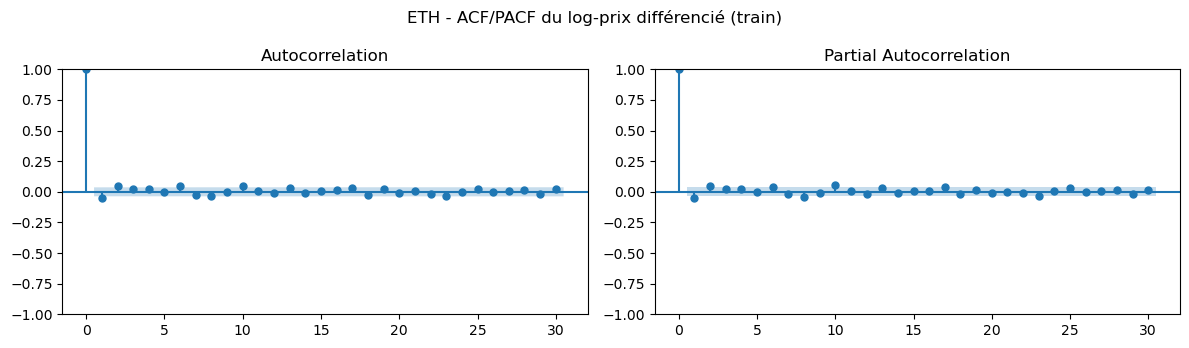

In [3]:
#ACF/PACF de la série différenciée (sur le train)
for a in ["btc", "eth"]:
    y_train = df.loc[:split["train_end"], f"{a}_logp"]     # log-prix, train seulement
    dy = y_train.diff().dropna()                            # série différenciée = rendements

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    plot_acf(dy, lags=30, ax=axes[0])
    plot_pacf(dy, lags=30, ax=axes[1], method="ywm")
    fig.suptitle(f"{a.upper()} - ACF/PACF du log-prix différencié (train)")
    fig.tight_layout()
    fig.savefig(f"results/figures/02_acf_pacf_diff_{a}.png", dpi=150)
    plt.show()

In [5]:
# Choix des ordres : grille manuelle + auto_arima
resultats = []
for a in ["btc", "eth"]:
    y_train = df.loc[:split["train_end"], f"{a}_logp"]

    # grille manuelle : ARIMA(p,1,q) avec p, q de 0 à 2, sans et avec dérive
    for p in range(3):
        for q in range(3):
            for trend in ["n", "t"]:                       # "n" = sans dérive, "t" = avec dérive
                m = ARIMA(y_train, order=(p, D, q), trend=trend).fit()
                resultats.append({"actif": a.upper(), "methode": "manuelle", "p": p, "q": q,
                                  "derive": trend == "t", "AIC": round(m.aic, 2), "BIC": round(m.bic, 2)})

    # sélection automatique (équivalent de auto.arima en R)
    auto = pm.auto_arima(y_train, d=D, seasonal=False, stepwise=True,
                         information_criterion="aic", suppress_warnings=True)
    p, _, q = auto.order
    trend = "t" if auto.with_intercept else "n"
    m = ARIMA(y_train, order=(p, D, q), trend=trend).fit()
    resultats.append({"actif": a.upper(), "methode": "auto_arima", "p": p, "q": q,
                      "derive": trend == "t", "AIC": round(m.aic, 2), "BIC": round(m.bic, 2)})

ordres = pd.DataFrame(resultats)
ordres.to_csv("results/tables/02_selection_ordres.csv", index=False)

# meilleur modèle par critère, pour chaque actif
for a in ["BTC", "ETH"]:
    t = ordres[ordres.actif == a]
    print(a, "| meilleur BIC :", t.loc[t.BIC.idxmin(), ["p", "q", "derive", "BIC"]].to_dict())
    print(a, "| meilleur AIC :", t.loc[t.AIC.idxmin(), ["p", "q", "derive", "AIC"]].to_dict())

ordres.sort_values(["actif", "BIC"]).groupby("actif").head(5)    # top 5 par actif

BTC | meilleur BIC : {'p': 0, 'q': 0, 'derive': False, 'BIC': -11198.83}
BTC | meilleur AIC : {'p': 2, 'q': 0, 'derive': False, 'AIC': -11212.57}
ETH | meilleur BIC : {'p': 0, 'q': 0, 'derive': False, 'BIC': -9638.05}
ETH | meilleur AIC : {'p': 1, 'q': 2, 'derive': False, 'AIC': -9655.28}


,actif,methode,p,q,derive,AIC,BIC
0,BTC,manuelle,0,0,False,-11204.80,-11198.83
6,BTC,manuelle,1,0,False,-11209.14,-11197.21
2,BTC,manuelle,0,1,False,-11208.59,-11196.66
12,BTC,manuelle,2,0,False,-11212.57,-11194.68
18,BTC,auto_arima,2,0,False,-11212.57,-11194.68
19,ETH,manuelle,0,0,False,-9644.01,-9638.05
25,ETH,manuelle,1,0,False,-9648.98,-9637.05
21,ETH,manuelle,0,1,False,-9648.34,-9636.41
23,ETH,manuelle,0,2,False,-9654.11,-9636.22
31,ETH,manuelle,2,0,False,-9653.80,-9635.91


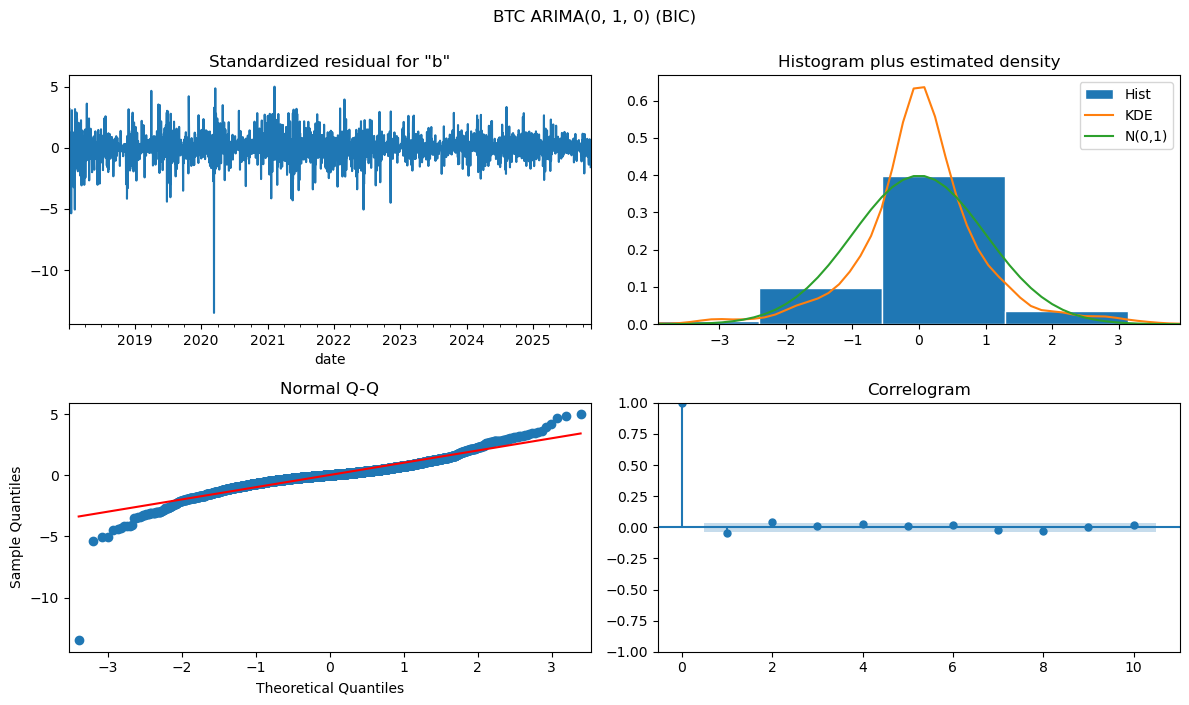

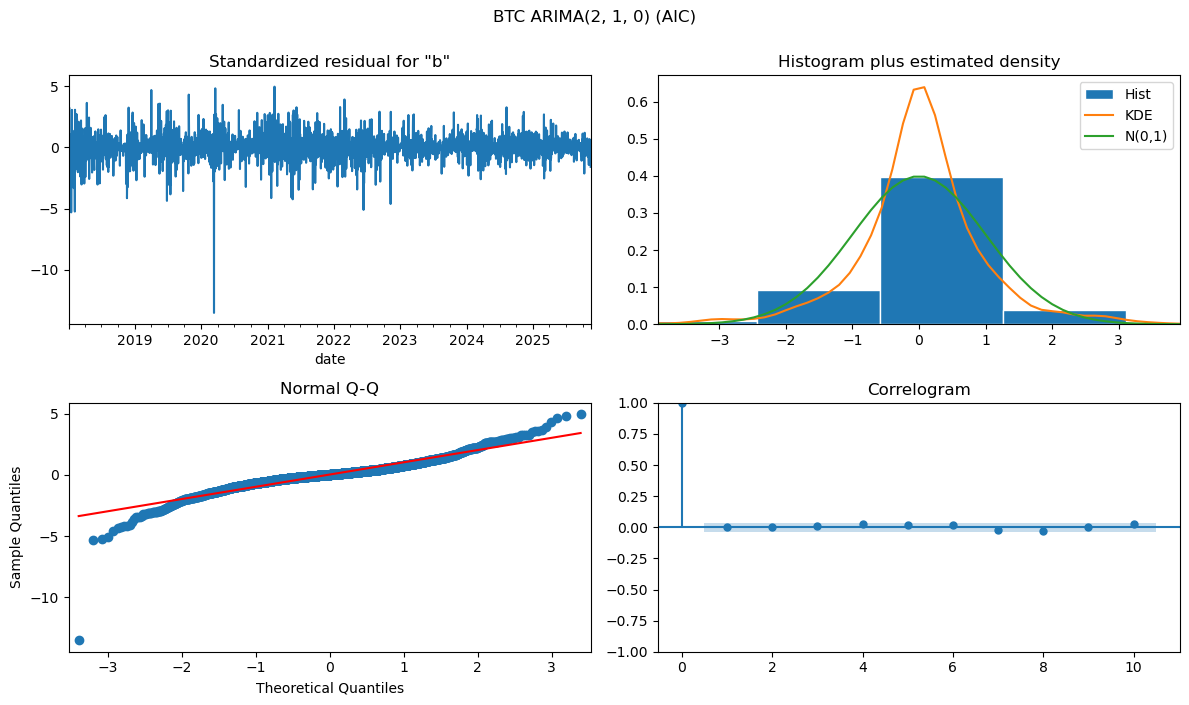

BTC SARIMA : AIC -11209.7 vs ARIMA -11212.6 | p saisonniers {'ar.S.L7': 0.6178, 'ma.S.L7': 0.5973} -> rejeté


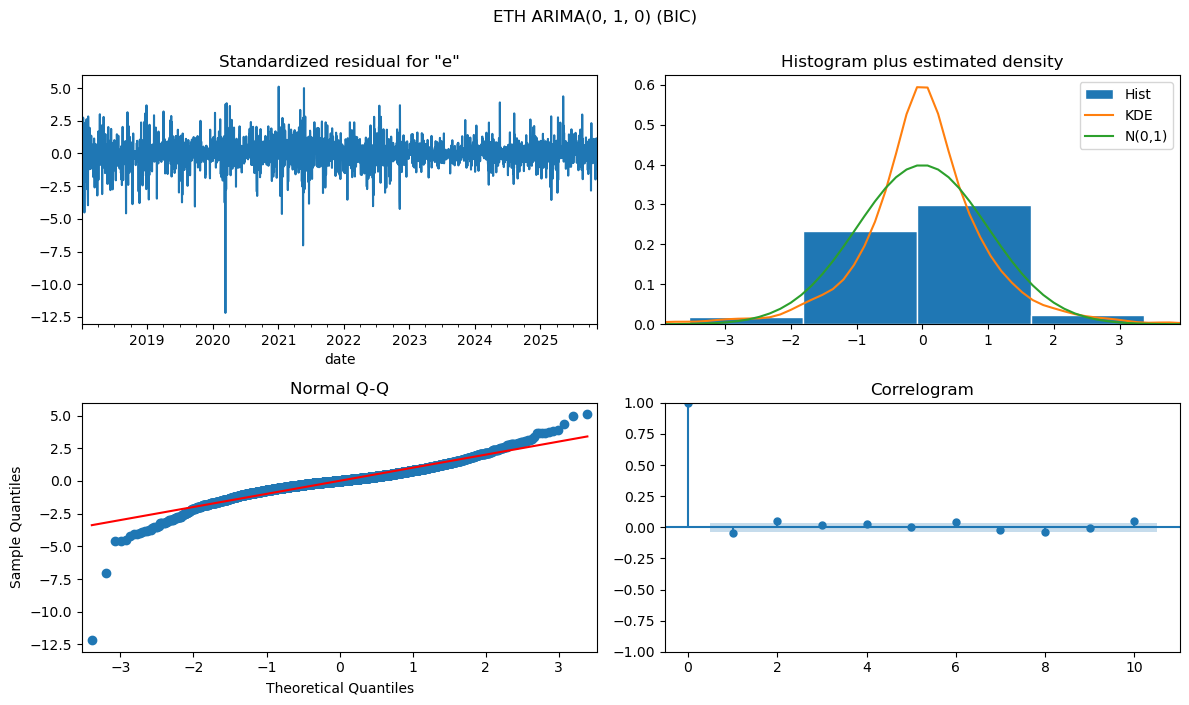

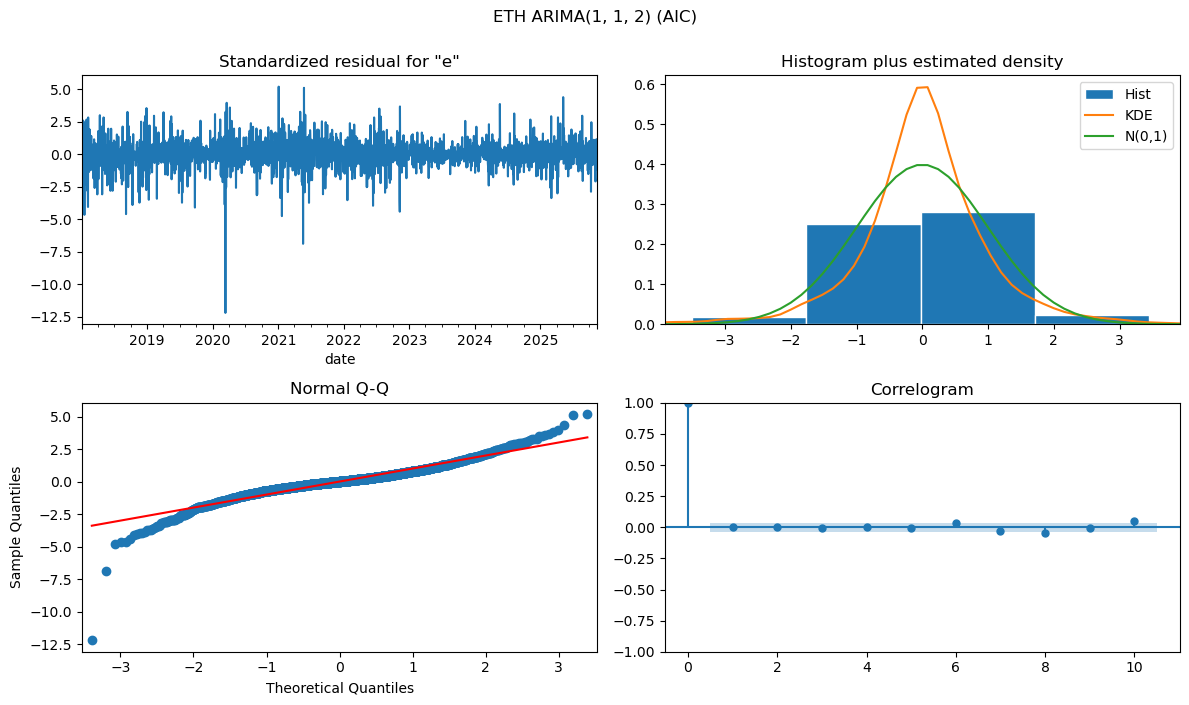

ETH SARIMA : AIC -9654.2 vs ARIMA -9655.3 | p saisonniers {'ar.S.L7': 0.5616, 'ma.S.L7': 0.5035} -> rejeté


,modele,LB_p_10,LB_p_20,JB_p,Shapiro_p,ARCH_LM_p
0,"BTC ARIMA(0, 1, 0) (BIC)",0.0225,0.1167,0.0,0.0,0.0
1,"BTC ARIMA(2, 1, 0) (AIC)",0.4758,0.7105,0.0,0.0,0.0
2,"ETH ARIMA(0, 1, 0) (BIC)",0.0001,0.0008,0.0,0.0,0.0
3,"ETH ARIMA(1, 1, 2) (AIC)",0.0307,0.0772,0.0,0.0,0.0


In [7]:
#Diagnostic des résidus + test SARIMA
def diagnostic(resid, nom):
    e = resid.dropna().iloc[1:]                               # 1re valeur = artefact de la différenciation
    lb = acorr_ljungbox(e, lags=[10, 20], return_df=True)     # autocorrélation des résidus
    jb = stats.jarque_bera(e)                                 # normalité
    sh = stats.shapiro(e[-5000:])                             # normalité (Shapiro limité à 5000 obs.)
    arch = het_arch(e, nlags=10)                              # effet ARCH
    return {"modele": nom,
            "LB_p_10": round(lb["lb_pvalue"].iloc[0], 4), "LB_p_20": round(lb["lb_pvalue"].iloc[1], 4),
            "JB_p": round(jb.pvalue, 4), "Shapiro_p": round(sh.pvalue, 4),
            "ARCH_LM_p": round(arch[1], 4)}

modeles = {}        # modèles retenus, réutilisés pour les prévisions
diags = []
for a in ["btc", "eth"]:
    y_train = df.loc[:split["train_end"], f"{a}_logp"]
    t = ordres[ordres.actif == a.upper()]

    for crit in ["BIC", "AIC"]:
        b = t.loc[t[crit].idxmin()]                          # meilleur modèle selon le critère
        order, trend = (int(b.p), D, int(b.q)), ("t" if b.derive else "n")
        if (a, order, trend) in [(k[0], v[0], v[1]) for k, v in modeles.items()]:
            continue                                         # même modèle que le BIC -> on ne le refait pas
        m = ARIMA(y_train, order=order, trend=trend).fit()
        modeles[(a, crit)] = (order, trend)
        nom = f"{a.upper()} ARIMA{order}{' + dérive' if trend == 't' else ''} ({crit})"
        diags.append(diagnostic(m.resid, nom))

        fig = m.plot_diagnostics(figsize=(12, 7))            # 4 graphes des résidus
        fig.suptitle(nom, y=1.0)
        fig.tight_layout()
        fig.savefig(f"results/figures/02_residus_{a}_{crit}.png", dpi=150)
        plt.show()

    # SARIMA : saisonnalité hebdomadaire (s = 7) testée sur le dernier modèle retenu
    sar = SARIMAX(y_train, order=order, seasonal_order=(1, 0, 1, 7),
                  trend="c" if trend == "t" else "n").fit(disp=False)
    p_saison = sar.pvalues.filter(like="S.L7")
    garder = (sar.aic < m.aic) and (p_saison < 0.05).any()
    print(f"{a.upper()} SARIMA : AIC {sar.aic:.1f} vs ARIMA {m.aic:.1f} | p saisonniers {p_saison.round(4).to_dict()}",
          "-> gardé" if garder else "-> rejeté")

diag_tab = pd.DataFrame(diags)
diag_tab.to_csv("results/tables/02_diagnostic_residus.csv", index=False)
diag_tab

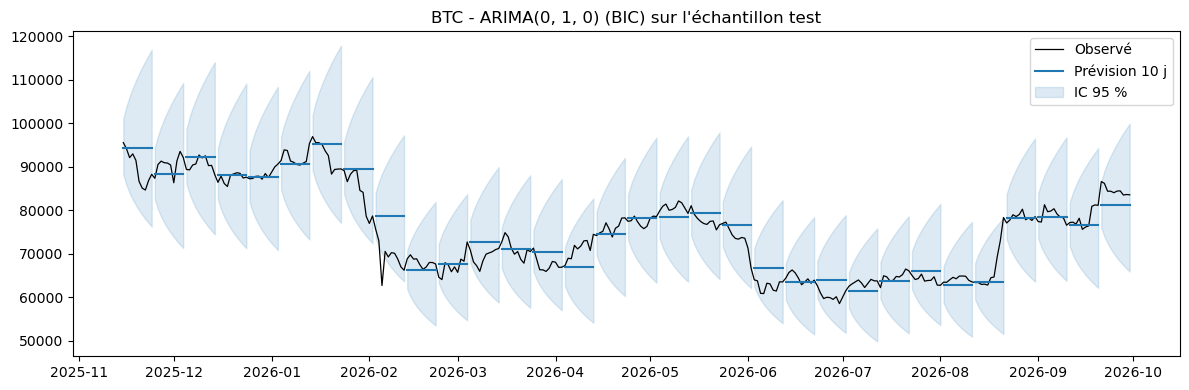

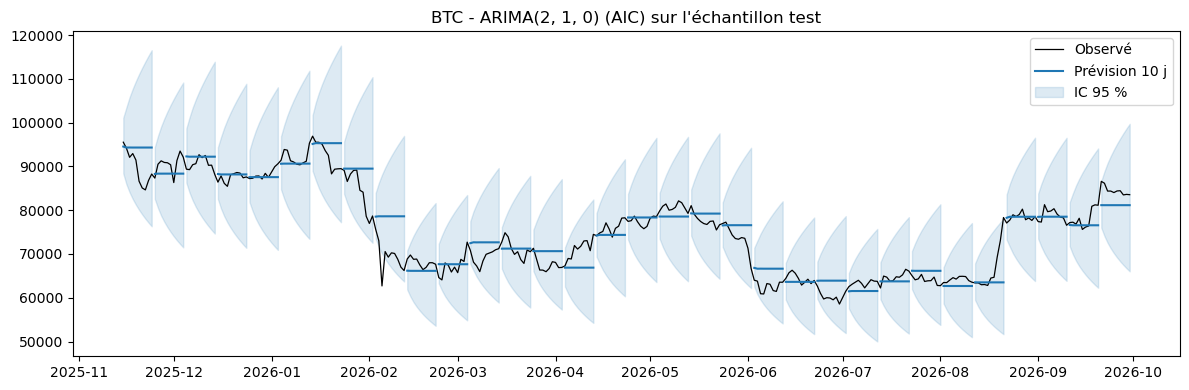

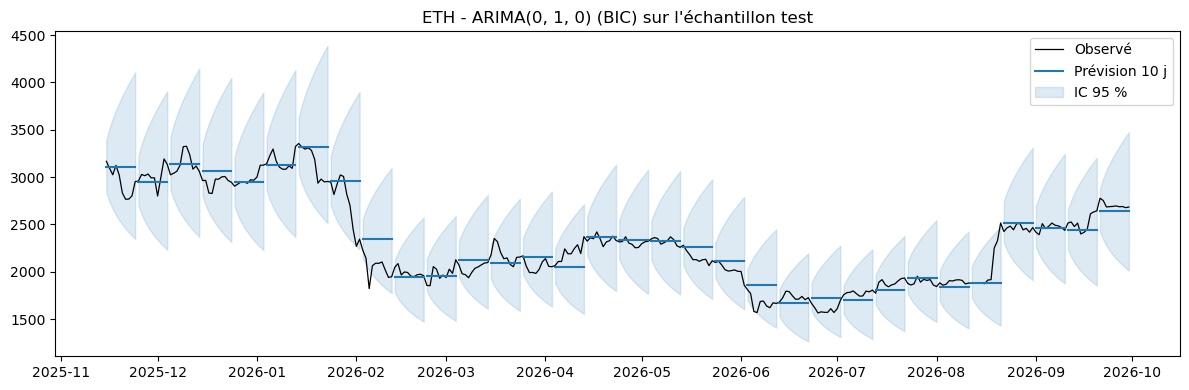

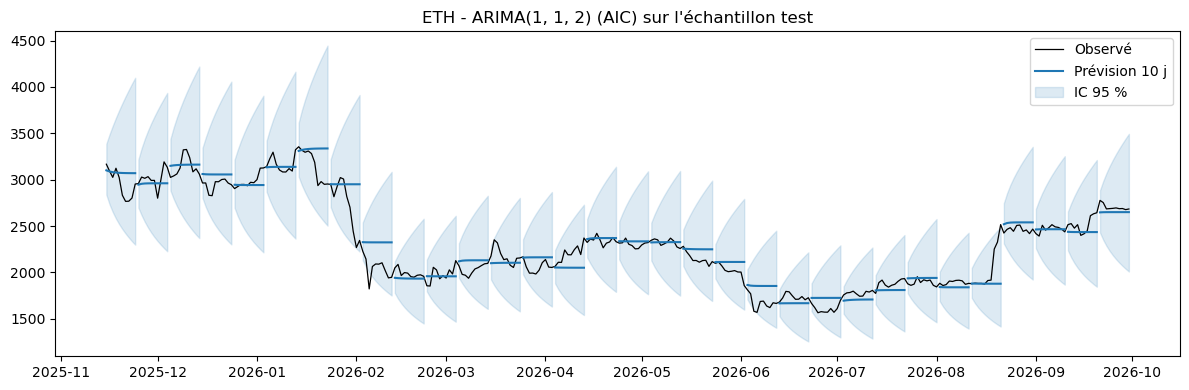

,actif,modele,MSE,RMSE,MAE,MAPE_%,couverture_IC95,temps_s
0,BTC,"ARIMA(0, 1, 0) (BIC)",1.300813e+07,3606.6784,2561.7543,3.4935,0.9938,7.1
1,BTC,"ARIMA(2, 1, 0) (AIC)",1.295346e+07,3599.0921,2559.3523,3.4909,0.9938,22.9
2,BTC,Naive,1.300813e+07,3606.6784,2561.7543,3.4935,NaN,0.1
3,BTC,Drift,1.353815e+07,3679.4231,2594.1025,3.5395,NaN,0.1
4,ETH,"ARIMA(0, 1, 0) (BIC)",2.102587e+04,145.0030,99.5276,4.4802,0.9875,11.6
5,ETH,"ARIMA(1, 1, 2) (AIC)",2.045618e+04,143.0251,99.2790,4.4650,0.9906,44.9
6,ETH,Naive,2.102587e+04,145.0030,99.5276,4.4802,NaN,0.1
7,ETH,Drift,2.152519e+04,146.7147,100.6127,4.5263,NaN,0.1


In [8]:
#Prévisions et évaluation
def rolling_origin(a, prevoir):
    logp, prix = df[f"{a}_logp"], df[f"{a}_close"]
    debut = pd.Timestamp(split["test_start"])
    origines = [o for o in pd.date_range(debut, df.index[-1], freq="10D")
                if o + pd.Timedelta(days=H - 1) <= df.index[-1]]          # une origine tous les 10 jours
    lignes = []
    for o in origines:
        hist = logp[: o - pd.Timedelta(days=1)]                            # seulement le passé
        moy, bas, haut = prevoir(hist)
        dates = pd.date_range(o, periods=H, freq="D")
        for h in range(H):
            lignes.append({"origin": o.date(), "date": dates[h].date(), "h": h + 1,
                           "y_true": prix[dates[h]], "y_pred": np.exp(moy[h]),   # retour au prix en USD
                           "lo95": np.exp(bas[h]) if bas is not None else np.nan,
                           "hi95": np.exp(haut[h]) if haut is not None else np.nan})
    return pd.DataFrame(lignes)

def prev_arima(order, trend):
    def f(hist):
        r = ARIMA(hist, order=order, trend=trend).fit()                   # ré-estimé à chaque origine
        fc = r.get_forecast(H)
        ic = fc.conf_int(alpha=0.05)                                      # intervalle à 95 %
        return fc.predicted_mean.values, ic.iloc[:, 0].values, ic.iloc[:, 1].values
    return f

def naive(hist):                                                          # demain = aujourd'hui
    return np.repeat(hist.iloc[-1], H), None, None

def drift(hist):                                                          # tendance moyenne prolongée
    pente = (hist.iloc[-1] - hist.iloc[0]) / (len(hist) - 1)
    return hist.iloc[-1] + pente * np.arange(1, H + 1), None, None

def metriques(fc):
    e = fc["y_true"] - fc["y_pred"]
    return {"MSE": np.mean(e**2), "RMSE": np.sqrt(np.mean(e**2)), "MAE": np.mean(np.abs(e)),
            "MAPE_%": 100 * np.mean(np.abs(e / fc["y_true"]))}            # sur le prix, pas les rendements

res, res_h = [], []
for a in ["btc", "eth"]:
    candidats = [(f"ARIMA{o} ({c})", f"arima_{c.lower()}", prev_arima(o, t))
                 for (aa, c), (o, t) in modeles.items() if aa == a]
    candidats += [("Naive", "naive", naive), ("Drift", "drift", drift)]

    for nom, code, f in candidats:
        t0 = time.time()
        fc = rolling_origin(a, f)
        duree = time.time() - t0
        fc.to_csv(f"results/tables/forecasts_{code}_{a}.csv", index=False)     # pour Personne 3
        couv = ((fc.y_true >= fc.lo95) & (fc.y_true <= fc.hi95)).mean() if fc.lo95.notna().any() else np.nan
        res.append({"actif": a.upper(), "modele": nom, **metriques(fc),
                    "couverture_IC95": couv, "temps_s": round(duree, 1)})
        for h in [1, 5, 10]:
            res_h.append({"actif": a.upper(), "modele": nom, "h": h, **metriques(fc[fc.h == h])})

        if code.startswith("arima"):                                    # graphe des prévisions
            fig, ax = plt.subplots(figsize=(12, 4))
            ax.plot(df.loc[split["test_start"]:, f"{a}_close"], color="black", lw=0.9, label="Observé")
            for i, (o, g) in enumerate(fc.groupby("origin")):
                d = pd.to_datetime(g.date)
                ax.plot(d, g.y_pred, color="tab:blue", label="Prévision 10 j" if i == 0 else None)
                ax.fill_between(d, g.lo95, g.hi95, color="tab:blue", alpha=0.15, label="IC 95 %" if i == 0 else None)
            ax.set_title(f"{a.upper()} - {nom} sur l'échantillon test")
            ax.legend()
            fig.tight_layout()
            fig.savefig(f"results/figures/02_previsions_{a}_{code}.png", dpi=150)
            plt.show()

metr = pd.DataFrame(res).round(4)
metr.to_csv("results/tables/02_metriques.csv", index=False)
pd.DataFrame(res_h).round(4).to_csv("results/tables/02_metriques_par_horizon.csv", index=False)
metr